In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')


In [17]:
data=pd.read_csv("student_dataset.csv")
df=pd.DataFrame(data)
df=df.dropna()
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,60,No,6,Yes
2,8,90,75,Yes,8,Yes
3,3,70,50,Yes,5,No
4,7,85,70,No,7,Yes


DataSet shape

In [18]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 20, Columns: 6


DataSet info.

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None


DataSet summary sataistics

In [20]:
print(df.describe(include="all"))

        StudyHours  Attendance  PastScore Internet  SleepHours Passed
count    20.000000   20.000000   20.00000       20   20.000000     20
unique         NaN         NaN        NaN        2         NaN      2
top            NaN         NaN        NaN      Yes         NaN    Yes
freq           NaN         NaN        NaN       11         NaN     11
mean      5.100000   74.150000   59.10000      NaN    6.050000    NaN
std       2.845125   17.372922   19.41215      NaN    2.038446    NaN
min       1.000000   40.000000   25.00000      NaN    3.000000    NaN
25%       2.750000   60.000000   43.75000      NaN    4.750000    NaN
50%       5.000000   77.000000   62.50000      NaN    6.000000    NaN
75%       7.250000   88.500000   72.75000      NaN    7.250000    NaN
max      10.000000   99.000000   90.00000      NaN   10.000000    NaN


Label encoding of Internet and passed

In [21]:

labelencode=LabelEncoder()
labelencoded_internet=labelencode.fit_transform(df['Internet'])
df['Internet']=labelencoded_internet

labelencoded_passed=labelencode.fit_transform(df['Passed'])
df['Passed']=labelencoded_passed
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,60,0,6,1
2,8,90,75,1,8,1
3,3,70,50,1,5,0
4,7,85,70,0,7,1


Standard scaling

In [22]:
features=['StudyHours','Attendance','PastScore','SleepHours']
scalar=StandardScaler()
df_scaled=df.copy()
df_scaled=scalar.fit_transform(df[features])
df_scaled


array([[-1.11788859, -0.8356449 , -1.00948047, -0.5284796 ],
       [-0.03606092,  0.34547863,  0.04756714, -0.0251657 ],
       [ 1.04576675,  0.9360404 ,  0.84035285,  0.98146212],
       [-0.75727937, -0.24508313, -0.48095666, -0.5284796 ],
       [ 0.68515752,  0.64075952,  0.57609095,  0.47814821],
       [-1.47849781, -1.42620666, -1.53800427, -1.03179351],
       [ 0.3245483 ,  0.22736628,  0.47038619, -0.0251657 ],
       [-0.39667015, -0.54036402, -0.21669476, -0.5284796 ],
       [ 1.40637597,  1.23132128,  1.10461475,  1.48477603],
       [-1.11788859, -1.13092578, -1.27374237, -1.03179351],
       [-0.03606092,  0.10925393,  0.31182904, -0.0251657 ],
       [ 0.3245483 ,  0.81792804,  0.68179571,  0.47814821],
       [-1.47849781, -2.01676843, -1.80226617, -1.53510742],
       [-0.75727937, -0.8356449 , -0.74521856, -1.03179351],
       [ 1.04576675,  1.05415275,  0.99890999,  0.98146212],
       [ 0.68515752,  0.58170334,  0.52323857,  0.47814821],
       [-0.39667015, -0.

spliting data (train and test)

In [23]:
X=pd.DataFrame(df_scaled,columns=features)
y=df['Passed']

XTrain,XTest,yTrain,YTest=train_test_split(X,y,train_size=0.2,random_state=42)

Logistic Regression

In [24]:
model=LogisticRegression()
model.fit(XTrain,yTrain)

yPred=model.predict(XTest)

Classification report

In [25]:
print(f"classification Report: {classification_report(YTest,yPred)}")

classification Report:               precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.80      1.00      0.89         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



Confusion matrix

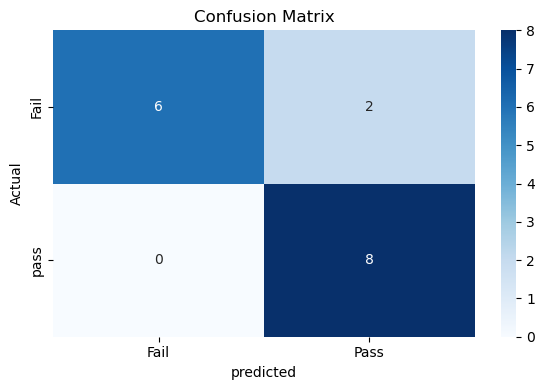

In [26]:
conf_mat=confusion_matrix(YTest,yPred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_mat,annot=True,fmt='d',cmap="Blues",xticklabels=['Fail','Pass'],yticklabels=['Fail','pass'])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Input

In [27]:
try:
    study_hours=float(input("Enter study hours: "))
    attendance=float(input("Enter attendance: "))
    past_score=float(input("Enter past score: "))
    sleep_hours=float(input("Enter sleep hours: "))

    userinput_df=pd.DataFrame([{
        "StudyHours": study_hours,
        "Attendance": attendance,
        "PastScore": past_score,
        "SleepHours": sleep_hours
    }])

    userinput_scaled=scalar.fit_transform(userinput_df)
    prediction=model.predict(userinput_scaled)[0]
    
    if prediction==1:
        print("pass")
    else:
        print("Fail")
except :
    print("An error occured")



pass


Cluster

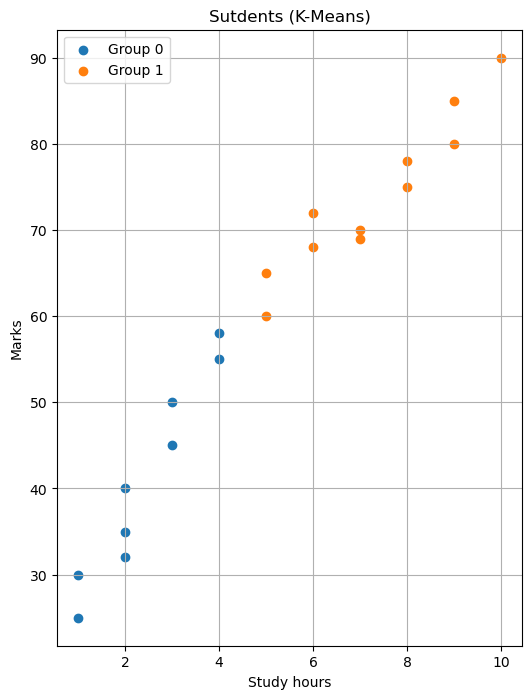

    StudyHours  Attendance  PastScore  Internet  SleepHours  Passed  Group
0            2          60         40         1           5       0      0
1            5          80         60         0           6       1      1
2            8          90         75         1           8       1      1
3            3          70         50         1           5       0      0
4            7          85         70         0           7       1      1
5            1          50         30         0           4       0      0
6            6          78         68         1           6       1      1
7            4          65         55         0           5       0      0
8            9          95         80         1           9       1      1
9            2          55         35         0           4       0      0
10           5          76         65         1           6       1      1
11           6          88         72         1           7       1      1
12           1          4

In [31]:
X=df[features]

model=KMeans(n_clusters=2,n_init=10,random_state=42)
df["Group"]=model.fit_predict(X)

plt.figure(figsize=(6,8))
for group in df['Group'].unique():
    group_data=df[df['Group']==group]
    plt.scatter(group_data['StudyHours'],group_data['PastScore'],label=f"Group {group}")
plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.title("Sutdents (K-Means)")
plt.legend()
plt.grid(True)
plt.show()
print(df)
